In [1]:

import matplotlib.pyplot as plt
import numpy as np

import gpflow
from gpflow.ci_utils import reduce_in_tests
from atlikelihood import TransferLikelihood
from atmodel import ConditionalMOGP, AdaptiveTransferGPR
from atkernel import TransferKernel

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(123)

2026-03-26 18:29:24.143320: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 18:29:24.145798: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 18:29:24.194995: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 18:29:24.195903: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-26 18:29:24.780174: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

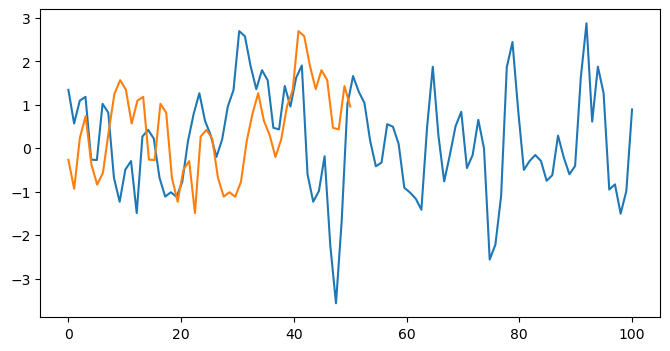

In [2]:
# make a dataset with two outputs, correlated, heavy-tail noise. One has more noise than the other.
X1 = np.linspace(0, 100, 100)[:,None]  # Observed locations for first output
X2 = np.linspace(0, 50, 50)[:,None] # Observed locations for second output

Xall = np.linspace(0, 110, 110).reshape(-1, 1)
k = gpflow.kernels.RBF(active_dims=[0])
Yall  = np.random.multivariate_normal(np.zeros_like(Xall[:,0]), k(Xall))
Y1 = Yall[10:110][:,None]
Y2 = Yall[0:50][:,None]
# Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.03
# Y2 = np.sin(6 * X2 + 0.7) + np.random.randn(*X2.shape) * 0.1

plt.figure(figsize=(8, 4))
plt.plot(X1, Y1, mew=2)
plt.plot(X2, Y2,  mew=2)

In [3]:
# Augment the input with ones or zeros to indicate the required output dimension
X_augmented = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
Y_augmented = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

In [4]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
kern2 = TransferKernel(0.5, gpflow.kernels.RBF(), source_length=int(len(Y_augmented) - np.sum(Y_augmented[:,1])))

condition number  3.0209901514669983 3.1525606545773512 1.0435521125570244
condition number  3.14494085047765 3.416318001691133 1.0862900652558429
tf.Tensor(-65.26430488609402, shape=(), dtype=float64)
condition number  3.14494085047765 3.416318001691133 1.0862900652558429
condition number  4.9898825080380425 4.1811035395078591 0.83791623004602878
condition number  4.9898825080380425 4.1811035395078591 0.83791623004602878
condition number  9.1312214276814316 5.3135193052652108 0.58190674132128684
condition number  9.1312214276814316 5.3135193052652108 0.58190674132128684
condition number  35.287104372841021 8.4330424024827924 0.23898368971791703
condition number  35.287104372841021 8.4330424024827924 0.23898368971791703
condition number  43.292510158750773 8.3549305226743318 0.19298789772266275
condition number  43.292510158750773 8.3549305226743318 0.19298789772266275
condition number  74.9401642730445 9.25506401656311 0.1234993825586275
condition number  53.003930693313947 8.65217097

2026-03-26 18:29:28.667571: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.670301: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.673836: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.676507: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.678839: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

condition number  nan nan nan
condition number  nan nan nan
condition number  nan nan nan
condition number  nan nan nan
condition number  nan nan nan
condition number  nan nan nan
condition number  nan nan nan
condition number  nan nan nan
condition number  46.174515592452643 5.9819552010147881 0.12955101151061249
condition number  39.263307918528191 6.0269228826328574 0.15350013032877388
condition number  39.263307918528191 6.0269228826328574 0.15350013032877388
condition number  39.2113938405132 6.0010721790285855 0.15304409232268298
condition number  39.2113938405132 6.0010721790285855 0.15304409232268298
condition number  37.560197487634561 5.6066529033510042 0.14927112417864169
condition number  38.615045511351447 5.84812899752925 0.15144690159202606
condition number  38.615045511351447 5.84812899752925 0.15144690159202606
condition number  37.799752092743027 5.7098723497513379 0.15105581475090007
condition number  38.38274978999091 5.8078476526147895 0.15131400653658494
condition

2026-03-26 18:29:28.869516: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.869714: E ./tensorflow/core/kernels/linalg/svd_op_impl.h:110] Eigen::BDCSVD failed with error code 3
2026-03-26 18:29:28.873009: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.873319: E ./tensorflow/core/kernels/linalg/svd_op_impl.h:110] Eigen::BDCSVD failed with error code 3
2026-03-26 18:29:28.878819: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:28.879165: E ./tensorflow/core/kernels/linalg/svd_op_impl.h:110] Eigen::BDCSVD failed with error code 3
2026-03-26 18:29:28.882915: 

condition number  38.315112320489973 5.7927078137418118 0.15118598022859026
condition number  38.31549253559907 5.792939131441015 0.15119051715331006
condition number  38.315593764891254 5.7930007459432842 0.15119172578897724
condition number  38.315593764891254 5.7930007459432842 0.15119172578897724
condition number  36.964690796604707 5.2137415285036424 0.141046534304638
condition number  38.271373717900062 5.7585591868875259 0.15046648780715616
condition number  38.308620686865247 5.7872425511790135 0.15106893559243356
condition number  38.314168794763546 5.791812384717419 0.15116633263642651
condition number  38.31052100066664 5.7887977816136855 0.15110203751896131
condition number  38.3134185909862 5.7911892020592495 0.151153027190889
condition number  38.314010559961886 5.7916808015982983 0.15116352261098454
condition number  38.313620022434755 5.7913563631849954 0.15115659548207228
condition number  38.313928131473617 5.7916122863336188 0.151162059563817
condition number  38.313

2026-03-26 18:29:29.698058: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:29.703200: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:29.705838: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:29.708209: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-03-26 18:29:29.710343: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

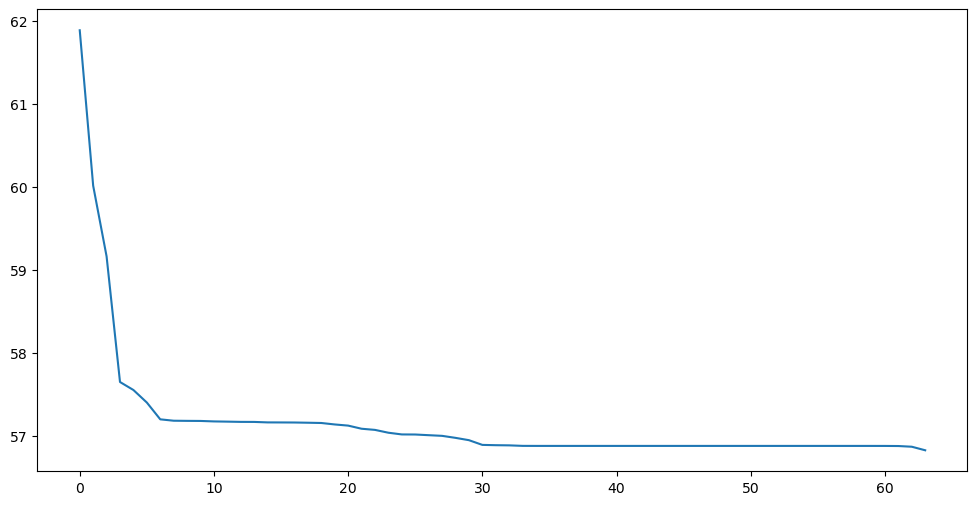

condition number  13.31768294439874 2.2254024007303626 0.16710132010361009
tf.Tensor(-61.451916317433465, shape=(), dtype=float64)
condition number  13.31768294439874 2.2254024007303626 0.16710132010361009
condition number  35.595563450981309 4.3369596566450825 0.12183989340743305
condition number  35.595563450981309 4.3369596566450825 0.12183989340743305
condition number  35.076529631828365 4.9994107999990955 0.14252866097285294
condition number  36.39837477948101 4.6477890419688652 0.12769221346083234
condition number  36.39837477948101 4.6477890419688652 0.12769221346083234
condition number  46.97274941958397 5.6109584316354368 0.11945135213431013
condition number  46.97274941958397 5.6109584316354368 0.11945135213431013
condition number  50.670411797643638 5.8628049056951523 0.1157047021663991
condition number  50.670411797643638 5.8628049056951523 0.1157047021663991
condition number  58.4262798387286 6.3293255277177716 0.10833011352405665
condition number  58.4262798387286 6.32932

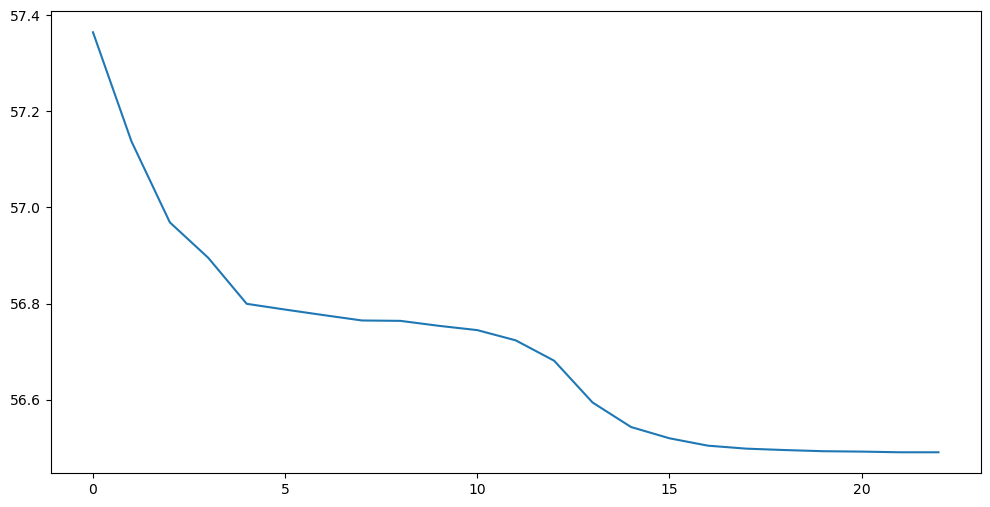

In [ ]:
from atkernel import TransferKernel
lik = TransferLikelihood(source=gpflow.likelihoods.Gaussian(), target=gpflow.likelihoods.Gaussian())
# now build the GP model as normal
m = ConditionalMOGP((X_augmented, Y_augmented), kernel=kern2, likelihood=lik)
m.conditional_likelihood()
for kernel in [kern, kern2]:
    m = ConditionalMOGP((X_augmented, Y_augmented), kernel=kernel, likelihood=lik)
    # fit the covariance function parameters
    print(m.maximum_log_likelihood_objective())
    res = gpflow.optimizers.Scipy().minimize(
        m.training_loss,
        m.trainable_variables,
        method="L-BFGS-B",
        track_loss_history=True
    )
    plt.plot(res["loss_history"])
    plt.show()
    plt.show()
plt.show()



In [6]:
from atkernel import TransferKernel
lik = TransferLikelihood(source=gpflow.likelihoods.Gaussian(), target=gpflow.likelihoods.Gaussian())
# now build the GP model as normal
for kernel in [kern2]:
    m = AdaptiveTransferGPR(data_source=(X1, Y1), data_target=(X2, Y2), base_kernel=gpflow.kernels.RBF())
    print(m.maximum_log_likelihood_objective())
    res = gpflow.optimizers.Scipy().minimize(
        m.training_loss,
        m.trainable_variables,
        method="L-BFGS-B",
        track_loss_history=True
    )
    print(res["loss_history"])
    plt.plot(res["loss_history"])
    plt.show()
    plot_gpr(m)
    plt.show()

TypeError: AdaptiveTransferGPR.__init__() got an unexpected keyword argument 'base_kernel'

In [ ]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()


def plot_gpr(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(Xtest)
    (line,) = plt.plot(X2, Y2, "x", mew=2)
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()



In [ ]:
m

NameError: name 'm' is not defined

In [ ]:
Xtest = np.linspace(0, 1, 100)[:, None]
Xtest = np.hstack((Xtest, np.zeros_like(Xtest)))
plt.imshow(m.kernel(Xtest))

B = coreg.output_covariance().numpy()
print("B =", B)
plt.imshow(B)

NameError: name 'm' is not defined